In [12]:
# Chat GPT template:

'''
# Section 1 — Load Data


from src.data_loader import load_data

df = load_data("../data/raw/happiness.csv")

df.head()
df.info()

# Section 2 — Clean Data
from src.cleaning import clean_columns, drop_missing

df = clean_columns(df)
df = drop_missing(df)

# Section 3 — Basic Exploration
df.describe()
df["country"].nunique()

# Section 4 — Core Analysis
# 1️⃣ Top happiest countries
df.groupby("country")["happiness_score"].mean().sort_values(ascending=False)

# -----------------------------------------------

# 2️⃣ Correlations (VERY IMPORTANT)
corr = df.corr(numeric_only=True)

import seaborn as sns
sns.heatmap(corr, annot=True)

# -----------------------------------------------

# 3️⃣ GDP vs Happiness
sns.scatterplot(data=df, x="gdp_per_capita", y="happiness_score")

# -----------------------------------------------

# 4️⃣ Trends over time
df.groupby("year")["happiness_score"].mean().plot()


# 📈 7. Outputs (save results!)

# Example:
df.groupby("country")["happiness_score"] \
  .mean() \
  .to_csv("../outputs/tables/country_happiness.csv")

'''



'\n# Section 1 — Load Data\n\n\nfrom src.data_loader import load_data\n\ndf = load_data("../data/raw/happiness.csv")\n\ndf.head()\ndf.info()\n\n# Section 2 — Clean Data\nfrom src.cleaning import clean_columns, drop_missing\n\ndf = clean_columns(df)\ndf = drop_missing(df)\n\n# Section 3 — Basic Exploration\ndf.describe()\ndf["country"].nunique()\n\n# Section 4 — Core Analysis\n# 1️⃣ Top happiest countries\ndf.groupby("country")["happiness_score"].mean().sort_values(ascending=False)\n\n# -----------------------------------------------\n\n# 2️⃣ Correlations (VERY IMPORTANT)\ncorr = df.corr(numeric_only=True)\n\nimport seaborn as sns\nsns.heatmap(corr, annot=True)\n\n# -----------------------------------------------\n\n# 3️⃣ GDP vs Happiness\nsns.scatterplot(data=df, x="gdp_per_capita", y="happiness_score")\n\n# -----------------------------------------------\n\n# 4️⃣ Trends over time\ndf.groupby("year")["happiness_score"].mean().plot()\n\n\n# 📈 7. Outputs (save results!)\n\n# Example:\ndf

In [13]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

In [14]:
import pandas as pd

In [15]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

BASE_DIR = Path("../")
DATA_DIR = BASE_DIR / "data"
RAW_DATA_PATH = DATA_DIR / "raw"
PROCESSED_DATA_PATH = DATA_DIR / "processed"
OUTPUT_FILE_FULL_PATH = PROCESSED_DATA_PATH / "combined_years.csv"

In [16]:
# Section 1 — Load Data
from src.data_loader import load_all_csvs

dfs = load_all_csvs(RAW_DATA_PATH)

In [17]:
dfs["2015"]

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Rwanda,Sub-Saharan Africa,154,3.465,0.03464,0.22208,0.77370,0.42864,0.59201,0.55191,0.22628,0.67042
154,Benin,Sub-Saharan Africa,155,3.340,0.03656,0.28665,0.35386,0.31910,0.48450,0.08010,0.18260,1.63328
155,Syria,Middle East and Northern Africa,156,3.006,0.05015,0.66320,0.47489,0.72193,0.15684,0.18906,0.47179,0.32858
156,Burundi,Sub-Saharan Africa,157,2.905,0.08658,0.01530,0.41587,0.22396,0.11850,0.10062,0.19727,1.83302


In [18]:
# Section 2 — Clean Data

#define dictionary for column name normalization. Based on predefined data of 2015-2019.

COLUMN_MAPPING = {
    # country
    "country": "country",
    "country_or_region": "country",

    # rank
    "happiness_rank": "rank",
    "overall_rank": "rank",

    # score
    "happiness_score": "happiness_score",
    "score": "happiness_score",

    # gdp
    "economy_gdp_per_capita": "gdp_per_capita",
    "economy_gdp_per_capita_": "gdp_per_capita",
    "gdp_per_capita": "gdp_per_capita",

    # social
    "family": "social_support",
    "social_support": "social_support",

    # health
    "health_life_expectancy": "life_expectancy",
    "healthy_life_expectancy": "life_expectancy",
    "health_life_expectancy_": "life_expectancy",
    "healthy_life_expectancy_": "life_expectancy",

    # freedom
    "freedom": "freedom",
    "freedom_to_make_life_choices": "freedom",

    # corruption
    "trust_government_corruption": "corruption",
    "perceptions_of_corruption": "corruption",
    "trust_government_corruption_": "corruption",
    "perceptions_of_corruption_": "corruption",

    # generosity
    "generosity": "generosity",

    # dystopia
    "dystopia_residual": "dystopia_residual",
}

In [19]:
# clean the names of all data frame columns so it can be worked with
# standardize the data frame according to column mapping and filter out unusuable ones.
# add file ID column to each so source can be identified after unification to one data frame.

from src.data_cleaner import normalize_columns, standardize_df

for data_set_name in dfs:
  dfs[data_set_name] = standardize_df(dfs[data_set_name], data_set_name, COLUMN_MAPPING)
  # TODO - add the original line number of the file as another column - to make debug easy later on


In [20]:
dfs['2017']

,country,rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,dystopia_residual,file_id
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,2017
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,2017
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,2017
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,2017
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,2017
...,...,...,...,...,...,...,...,...,...,...,...
150,Rwanda,151,3.471,0.368746,0.945707,0.326425,0.581844,0.252756,0.455220,0.540061,2017
151,Syria,152,3.462,0.777153,0.396103,0.500533,0.081539,0.493664,0.151347,1.061574,2017
152,Tanzania,153,3.349,0.511136,1.041990,0.364509,0.390018,0.354256,0.066035,0.621130,2017
153,Burundi,154,2.905,0.091623,0.629794,0.151611,0.059901,0.204435,0.084148,1.683024,2017


In [21]:
# unify all data frames to one data frame containing all data

combined_df = pd.concat(dfs, ignore_index=True)
combined_df

,country,rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,dystopia_residual,file_id
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2.51738,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2.70201,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2.49204,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2.46531,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2.45176,2015
...,...,...,...,...,...,...,...,...,...,...,...
777,Rwanda,152,3.334,0.35900,0.71100,0.61400,0.55500,0.21700,0.41100,NaN,2019
778,Tanzania,153,3.231,0.47600,0.88500,0.49900,0.41700,0.27600,0.14700,NaN,2019
779,Afghanistan,154,3.203,0.35000,0.51700,0.36100,0.00000,0.15800,0.02500,NaN,2019
780,Central African Republic,155,3.083,0.02600,0.00000,0.10500,0.22500,0.23500,0.03500,NaN,2019


In [22]:
# Data exploration and additional cleaning

# print(combined_df[combined_df['country'] == 'Israel'])

# corruption missing one entry - dystopia missing years 2018 and 2019 - removing the column
combined_df.drop(columns=["dystopia_residual"], inplace=True)

# minimal entry has some zeros accross almost every field. seems like empty data to check and filter out.
combined_df.describe()

# combined_df[combined_df["gdp_per_capita"] == 0]

# combined_df["country"].nunique()
# combined_df.loc[combined_df["file_id"] == '2015', "country"].nunique()
# combined_df.loc[combined_df["file_id"] == '2016', "country"].nunique()
# combined_df.loc[combined_df["file_id"] == '2017', "country"].nunique()
# combined_df.loc[combined_df["file_id"] == '2018', "country"].nunique()
# combined_df.loc[combined_df["file_id"] == '2019', "country"].nunique()

# seems like the numbers aren't exact - fetching the countries that show in all files:
# expected_years = combined_df["file_id"].nunique()

# missing_countries = (
#     combined_df.groupby("country")["file_id"].nunique()
#     .loc[lambda x: x < expected_years]
# )

# missing_countries

# seems : "Trinidad & Tobago", "Hong Kong", "Taiwan", all should be OK if name will be fixed
# combined_df[combined_df["country"].str.startswith("Taiwan", na=False)]
# searched for others - but all missing some years, so omitted.
# combined_df[combined_df['country'].str.contains("Gam", na=False)]



,rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,781.000000
mean,78.698210,5.379018,0.916047,1.078392,0.612416,0.411091,0.218576,0.125436
std,45.182384,1.127456,0.407340,0.329548,0.248309,0.152880,0.122321,0.105816
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,4.509750,0.606500,0.869363,0.440183,0.309768,0.130000,0.054000
50%,79.000000,5.322000,0.982205,1.124735,0.647310,0.431000,0.201982,0.091000
75%,118.000000,6.189500,1.236187,1.327250,0.808000,0.531000,0.278832,0.156030
max,158.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.838075,0.551910


In [23]:
# Additional cleaning after exploration of data

# remove lines with 0 in any of the following columns.
# TODO - pass column names to external file of configuration.
cols = ["gdp_per_capita", "social_support", "life_expectancy", "freedom", "generosity", "corruption"]

combined_df = combined_df[~(combined_df[cols] == 0).any(axis=1)]


# fixing names of same country with different entry:
# TODO - pass COUNTRY_NAME_FIX to external file of configuration.
COUNTRY_NAME_FIX = {
    'Trinidad': 'Trinidad and Tobago',
    'Hong Kong': 'Hong Kong',
    'Taiwan': 'Taiwan',
}

for key in COUNTRY_NAME_FIX:
  combined_df.loc[combined_df["country"].str.startswith(key, na=False),
    "country"
] = COUNTRY_NAME_FIX[key]

#removing countries that don't have all years entries
expected_years = combined_df["file_id"].nunique()

missing_countries = (
    combined_df.groupby("country")["file_id"].nunique()
    .loc[lambda x: x < expected_years]
)

combined_df = combined_df[~combined_df["country"].isin(missing_countries.index)]

# combined_df.sort_values(by=["file_id", "happiness_score"], ascending=[True, False])

combined_df.to_csv(OUTPUT_FILE_FULL_PATH, index=False)

In [24]:
combined_df

,country,rank,happiness_score,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,file_id
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957,2015
...,...,...,...,...,...,...,...,...,...,...
774,Syria,149,3.462,0.61900,0.37800,0.44000,0.01300,0.33100,0.14100,2019
775,Malawi,150,3.410,0.19100,0.56000,0.49500,0.44300,0.21800,0.08900,2019
776,Yemen,151,3.380,0.28700,1.16300,0.46300,0.14300,0.10800,0.07700,2019
777,Rwanda,152,3.334,0.35900,0.71100,0.61400,0.55500,0.21700,0.41100,2019


In [25]:
# Streamlit dashboard - generic for data (e.g. each column)

#Github - code space?


In [26]:
!pip install streamlit

2026-03-26 18:35:38.541 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 18:35:38.588 
  command:

    streamlit run C:\Users\Imanuel\PyCharmMiscProject\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-26 18:35:38.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 18:35:38.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 18:35:38.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 18:35:38.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 18:35:38.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 18:35:38.588 Thread

DeltaGenerator()

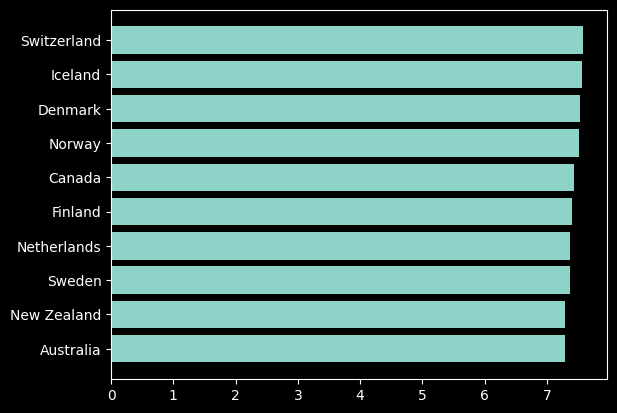

In [27]:
#visulaiastion

import streamlit as st
import matplotlib.pyplot as plt

st.title("🌍 World Happiness Dashboard")

years = sorted(combined_df["file_id"].unique())
selected_year = st.sidebar.selectbox("Select Year", years)

countries = sorted(combined_df["country"].unique())
selected_countries = st.sidebar.multiselect(
    "Select Countries (for trends)",
    countries,
    default=["Israel", "United States"]
)


# -------------------------
# Filtered data
# -------------------------
df_year = combined_df[combined_df["file_id"] == selected_year]

# -------------------------
# 1. Top Countries Bar Chart
# -------------------------
st.subheader(f"🏆 Top Countries in {selected_year}")

top_n = st.slider("Top N countries", 5, 20, 10)

top_df = df_year.sort_values(
    by="happiness_score",
    ascending=False
).head(top_n)

fig, ax = plt.subplots()
ax.barh(top_df["country"], top_df["happiness_score"])
ax.invert_yaxis()

st.pyplot(fig)
